# FWI SSP Scenario Comparison — MRI-ESM2-0 (hursmin) | Thailand
## Period 1: 2041–2050  |  Period 2: 2091–2100

Compares annual area-weighted mean FWI between SSP scenarios for the same decade.  
Data loaded from pre-computed cache (`computed_means_MRI-ESM2-0_hursmin`).

**Hypotheses (one-tailed, α = 0.05)**  
H₀ : FWI(SSP_high) ≤ FWI(SSP_low)  
H₁ : FWI(SSP_high) > FWI(SSP_low)

**Statistical approach:**
- Normality: Shapiro-Wilk test
- Non-normal → Wilcoxon Signed-Rank Test
- Normal → One-tailed paired t-test
- Effect size: Cohen’s *d* with 95% CI

## 1. Imports & Load Cache

In [3]:
import numpy as np
import xarray as xr
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path

CACHE_DIR = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin")

ssp119_mean_th = xr.open_dataarray(CACHE_DIR / "fwi_ssp119.nc").load()
ssp370_mean_th = xr.open_dataarray(CACHE_DIR / "fwi_ssp370.nc").load()
ssp585_mean_th = xr.open_dataarray(CACHE_DIR / "fwi_ssp585.nc").load()

def _sel_years(da, start, end):
    """Select annual values for year range [start, end] inclusive."""
    return da.sel(year=slice(start, end)).values

fwi_2041_2050_SSP119 = _sel_years(ssp119_mean_th, 2041, 2050)
fwi_2041_2050_SSP370 = _sel_years(ssp370_mean_th, 2041, 2050)
fwi_2041_2050_SSP585 = _sel_years(ssp585_mean_th, 2041, 2050)
fwi_2091_2100_SSP119 = _sel_years(ssp119_mean_th, 2091, 2100)
fwi_2091_2100_SSP370 = _sel_years(ssp370_mean_th, 2091, 2100)
fwi_2091_2100_SSP585 = _sel_years(ssp585_mean_th, 2091, 2100)

print("ssp119:", ssp119_mean_th["year"].values[[0, -1]])
print("ssp370:", ssp370_mean_th["year"].values[[0, -1]])
print("ssp585:", ssp585_mean_th["year"].values[[0, -1]])
print(f"\n2041–2050  n={len(fwi_2041_2050_SSP119)}  |  2091–2100  n={len(fwi_2091_2100_SSP119)}")

ssp119: [2015 2100]
ssp370: [2015 2100]
ssp585: [2015 2100]

2041–2050  n=10  |  2091–2100  n=10


## 2. Helper Functions

In [5]:
def cohens_d(x1, x2):
    """Pooled Cohen's d (positive = x2 > x1)."""
    n1, n2 = len(x1), len(x2)
    s_pooled = np.sqrt(
        ((n1 - 1) * np.var(x1, ddof=1) + (n2 - 1) * np.var(x2, ddof=1))
        / (n1 + n2 - 2)
    )
    return (np.mean(x2) - np.mean(x1)) / s_pooled


def _effect_label(d):
    d = abs(d)
    if d < 0.2: return "negligible"
    if d < 0.5: return "small"
    if d < 0.8: return "medium"
    return "large"


def mean_diff_ci(a, b, confidence=0.95):
    """95% CI for the difference in means (b − a)."""
    diff = np.mean(b) - np.mean(a)
    se = np.sqrt(np.var(a, ddof=1)/len(a) + np.var(b, ddof=1)/len(b))
    t_crit = stats.t.ppf((1 + confidence) / 2, df=min(len(a), len(b)) - 1)
    margin = t_crit * se
    return diff, diff - margin, diff + margin

## 3. SSP Comparison Function

In [7]:
def compare_ssp_same_decade(fwi_ssp1, fwi_ssp2, ssp1_label, ssp2_label,
                            decade, filename, alpha=0.05):
    """
    Compare FWI between two SSP scenarios for the same decade.
    H₀: FWI(ssp2) ≤ FWI(ssp1)   H₁: FWI(ssp2) > FWI(ssp1)  [one-tailed]
    """
    _, p1 = stats.shapiro(fwi_ssp1)
    _, p2 = stats.shapiro(fwi_ssp2)
    print(f"Shapiro-Wilk p-value ({ssp1_label}): {p1:.4f}")
    print(f"Shapiro-Wilk p-value ({ssp2_label}): {p2:.4f}")

    if p1 < alpha or p2 < alpha:
        print("Non-normal — applying Wilcoxon Signed-Rank Test.")
        diff = np.array(fwi_ssp2) - np.array(fwi_ssp1)
        if np.all(diff == 0):
            p_value, test_name = 1.0, "Wilcoxon (no variation)"
        else:
            _, p_value = stats.wilcoxon(fwi_ssp2, fwi_ssp1, alternative='greater')
            test_name = "Wilcoxon Signed-Rank Test"
    else:
        _, p_value = stats.ttest_rel(fwi_ssp2, fwi_ssp1, alternative='greater')
        test_name = "One-tailed Paired t-Test"

    print(f"\nTest: {test_name}")
    print(f"p-value: {p_value:.4f}")
    if p_value < alpha:
        print(f"Result: Reject H₀ — FWI of {ssp2_label} is significantly higher than {ssp1_label}.")
    else:
        print(f"Result: Fail to reject H₀ — no significant evidence that FWI of {ssp2_label} exceeds {ssp1_label}.")

    diff_val, ci_lo, ci_hi = mean_diff_ci(fwi_ssp1, fwi_ssp2)
    d_val = cohens_d(fwi_ssp1, fwi_ssp2)
    print(f"\nMean FWI ({ssp1_label}):         {np.mean(fwi_ssp1):.2f}")
    print(f"Mean FWI ({ssp2_label}):         {np.mean(fwi_ssp2):.2f}")
    print(f"Mean Difference (ssp2 − ssp1): {diff_val:.2f}")
    print(f"95% CI:                        ({ci_lo:.2f}, {ci_hi:.2f})")
    print(f"Cohen’s d:                     {d_val:.2f} ({_effect_label(d_val)})")

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.boxplot([fwi_ssp1, fwi_ssp2], tick_labels=[ssp1_label, ssp2_label])
    ax.set_ylabel("FWI")
    ax.set_title(f"FWI Comparison ({decade})\n{test_name}")
    ax.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()
    fig.savefig(filename + f"_SSP_Comparison_{decade}.png", dpi=300)
    plt.show()
    print("-" * 60)

## 4. Run Comparisons

Shapiro-Wilk p-value (SSP1-1.9): 0.9697
Shapiro-Wilk p-value (SSP5-8.5): 0.3826

Test: One-tailed Paired t-Test
p-value: 0.1323
Result: Fail to reject H₀ — no significant evidence that FWI of SSP5-8.5 exceeds SSP1-1.9.

Mean FWI (SSP1-1.9):         29.55
Mean FWI (SSP5-8.5):         30.67
Mean Difference (ssp2 − ssp1): 1.13
95% CI:                        (-0.80, 3.05)
Cohen’s d:                     0.59 (medium)


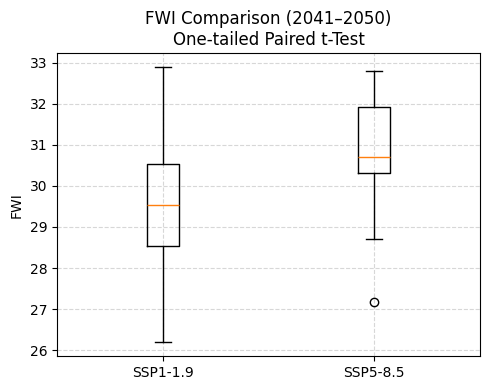

------------------------------------------------------------


In [9]:
# SSP1-1.9 vs SSP5-8.5  |  2041–2050
compare_ssp_same_decade(
    fwi_2041_2050_SSP119, fwi_2041_2050_SSP585,
    ssp1_label="SSP1-1.9", ssp2_label="SSP5-8.5",
    decade="2041–2050",
    filename="Pict/MRI_hursmin_fwi_comparison_2041s_119_585"
)

Shapiro-Wilk p-value (SSP1-1.9): 0.9697
Shapiro-Wilk p-value (SSP3-7.0): 0.2591

Test: One-tailed Paired t-Test
p-value: 0.5267
Result: Fail to reject H₀ — no significant evidence that FWI of SSP3-7.0 exceeds SSP1-1.9.

Mean FWI (SSP1-1.9):         29.55
Mean FWI (SSP3-7.0):         29.49
Mean Difference (ssp2 − ssp1): -0.06
95% CI:                        (-1.83, 1.71)
Cohen’s d:                     -0.03 (negligible)


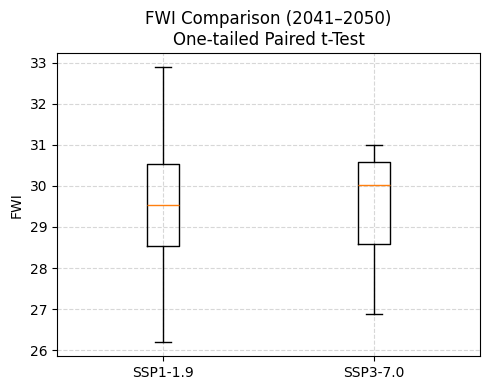

------------------------------------------------------------


In [10]:
# SSP1-1.9 vs SSP3-7.0  |  2041–2050
compare_ssp_same_decade(
    fwi_2041_2050_SSP119, fwi_2041_2050_SSP370,
    ssp1_label="SSP1-1.9", ssp2_label="SSP3-7.0",
    decade="2041–2050",
    filename="Pict/MRI_hursmin_fwi_comparison_2041s_119_370"
)

Shapiro-Wilk p-value (SSP1-1.9): 0.6157
Shapiro-Wilk p-value (SSP5-8.5): 0.0827

Test: One-tailed Paired t-Test
p-value: 0.0000
Result: Reject H₀ — FWI of SSP5-8.5 is significantly higher than SSP1-1.9.

Mean FWI (SSP1-1.9):         29.07
Mean FWI (SSP5-8.5):         36.30
Mean Difference (ssp2 − ssp1): 7.24
95% CI:                        (5.09, 9.39)
Cohen’s d:                     3.41 (large)


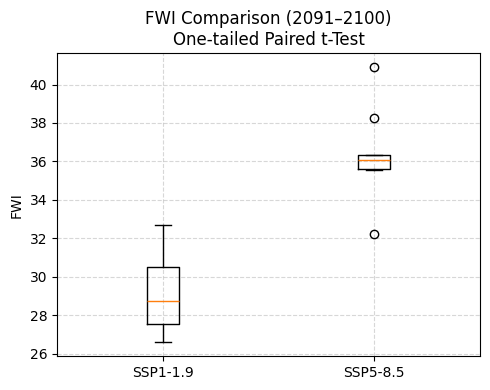

------------------------------------------------------------


In [11]:
# SSP1-1.9 vs SSP5-8.5  |  2091–2100
compare_ssp_same_decade(
    fwi_2091_2100_SSP119, fwi_2091_2100_SSP585,
    ssp1_label="SSP1-1.9", ssp2_label="SSP5-8.5",
    decade="2091–2100",
    filename="Pict/MRI_hursmin_fwi_comparison_2091s_119_585"
)

Shapiro-Wilk p-value (SSP1-1.9): 0.6157
Shapiro-Wilk p-value (SSP3-7.0): 0.4419

Test: One-tailed Paired t-Test
p-value: 0.0000
Result: Reject H₀ — FWI of SSP3-7.0 is significantly higher than SSP1-1.9.

Mean FWI (SSP1-1.9):         29.07
Mean FWI (SSP3-7.0):         34.12
Mean Difference (ssp2 − ssp1): 5.05
95% CI:                        (3.35, 6.75)
Cohen’s d:                     3.00 (large)


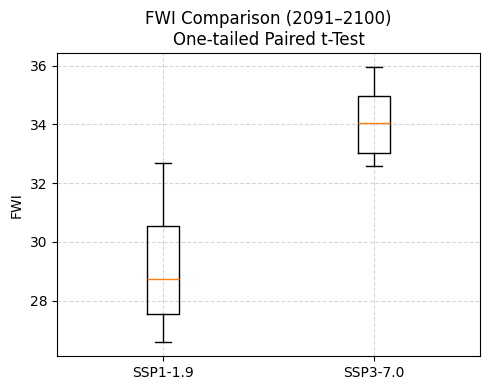

------------------------------------------------------------


In [12]:
# SSP1-1.9 vs SSP3-7.0  |  2091–2100
compare_ssp_same_decade(
    fwi_2091_2100_SSP119, fwi_2091_2100_SSP370,
    ssp1_label="SSP1-1.9", ssp2_label="SSP3-7.0",
    decade="2091–2100",
    filename="Pict/MRI_hursmin_fwi_comparison_2091s_119_370"
)